In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [3]:

df_match = pd.read_csv('matches.csv')
df_del = pd.read_csv('deliveries.csv')

In [4]:
df_match.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
df_match.shape

(1095, 20)

In [6]:
df_del.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [7]:
df_del.shape

(260920, 17)

In [8]:
df_match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [9]:
df_del.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [10]:
df_match['team1'].value_counts()

team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Punjab Kings                    31
Lucknow Super Giants            23
Pune Warriors                   23
Gujarat Titans                  21
Gujarat Lions                   16
Royal Challengers Bengaluru      9
Rising Pune Supergiant           7
Rising Pune Supergiants          7
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [11]:
df_match['team2'].value_counts()

team2
Mumbai Indians                 138
Kolkata Knight Riders          130
Rajasthan Royals               120
Chennai Super Kings            110
Royal Challengers Bangalore    105
Kings XI Punjab                 98
Sunrisers Hyderabad             96
Delhi Daredevils                76
Delhi Capitals                  50
Deccan Chargers                 36
Punjab Kings                    25
Gujarat Titans                  24
Pune Warriors                   23
Lucknow Super Giants            21
Gujarat Lions                   14
Rising Pune Supergiant           9
Rising Pune Supergiants          7
Kochi Tuskers Kerala             7
Royal Challengers Bengaluru      6
Name: count, dtype: int64

---DATA CLEANING---

In [12]:
df_match['team1'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
df_match['team2'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
df_match['toss_winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
df_match['winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)

C:\Users\Aryan Nigam\AppData\Local\Temp\ipykernel_1212\673326344.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_match['team1'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
C:\Users\Aryan Nigam\AppData\Local\Temp\ipykernel_1212\673326344.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we a

In [13]:
df_match['team1'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)
df_match['team2'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)
df_match['toss_winner'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)
df_match['winner'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)

In [14]:
df_match['team2'].value_counts()

team2
Mumbai Indians                 138
Kolkata Knight Riders          130
Rajasthan Royals               120
Royal Challengers Bangalore    111
Chennai Super Kings            110
Kings XI Punjab                 98
Sunrisers Hyderabad             96
Delhi Daredevils                76
Delhi Capitals                  50
Deccan Chargers                 36
Punjab Kings                    25
Gujarat Titans                  24
Pune Warriors                   23
Lucknow Super Giants            21
Rising Pune Supergiant          16
Gujarat Lions                   14
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [15]:
df_del['batting_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
df_del['bowling_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)

df_del['batting_team'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)
df_del['bowling_team'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)

C:\Users\Aryan Nigam\AppData\Local\Temp\ipykernel_1212\948179460.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_del['batting_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
C:\Users\Aryan Nigam\AppData\Local\Temp\ipykernel_1212\948179460.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which

In [16]:
df_del['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Royal Challengers Bangalore    30023
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          3480
Kochi Tuskers Kerala            1582
Name: count, dtype: int64

In [17]:
df_match['city'].isna().sum()

51

In [18]:
df_match['method'].value_counts()

method
D/L    21
Name: count, dtype: int64

In [20]:
df_match['city'] = df_match['city'].fillna('Unknown')
df_match['method'] = df_match['method'].fillna('Non D/L')

---Success Rate of Teams---

In [21]:
def random_colors(no_of_colors):
    return ['#'+''.join([np.random.choice(list('0123456789ABCDEF')) for _ in range(6)]) for _ in range(no_of_colors)]

In [22]:
random_colors(6)

['#B01E4D', '#CA3A64', '#94E8DD', '#0AEDEC', '#AC549E', '#AB6DDD']

C:\Users\Aryan Nigam\AppData\Local\Temp\ipykernel_1212\3329960302.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=success_ratio_desc.index,y=success_ratio_desc.values, palette=random_colors(len(success_ratio_desc)))


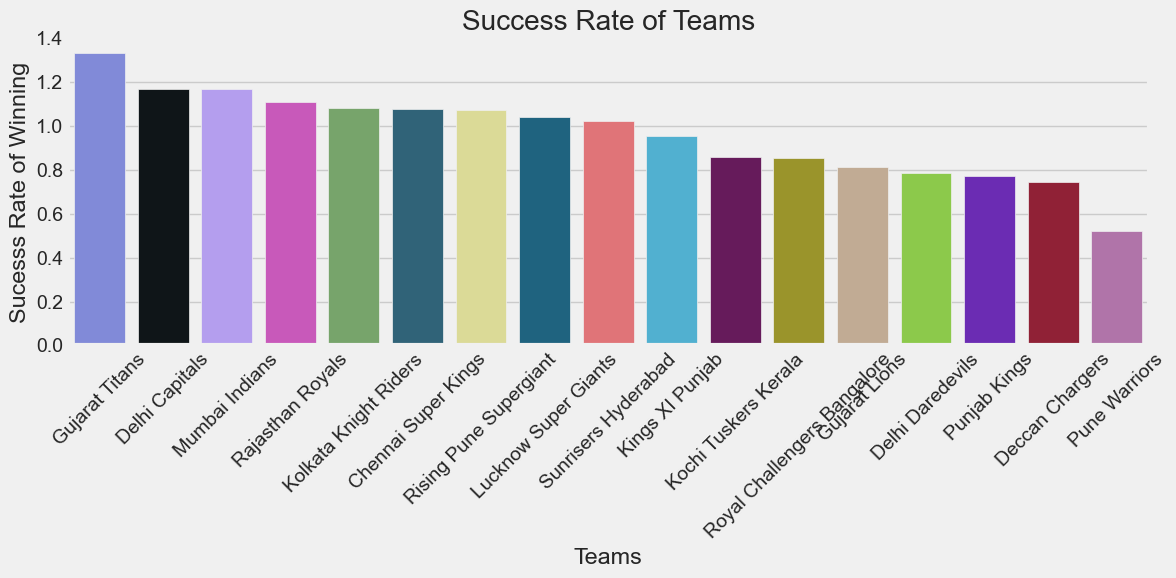

In [25]:
success_ratio = df_match.groupby('winner').count()['id']/df_match.groupby('team1').count()['id']
success_ratio_desc = success_ratio.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=success_ratio_desc.index,y=success_ratio_desc.values, palette=random_colors(len(success_ratio_desc)))
plt.title('Success Rate of Teams')
plt.xlabel('Teams')
plt.ylabel('Sucesss Rate of Winning')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

---Most Titles Won by Teams---

C:\Users\Aryan Nigam\AppData\Local\Temp\ipykernel_1212\1286710126.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=winner_counts.index,y=winner_counts.values, palette=random_colors(len(winner_counts)))


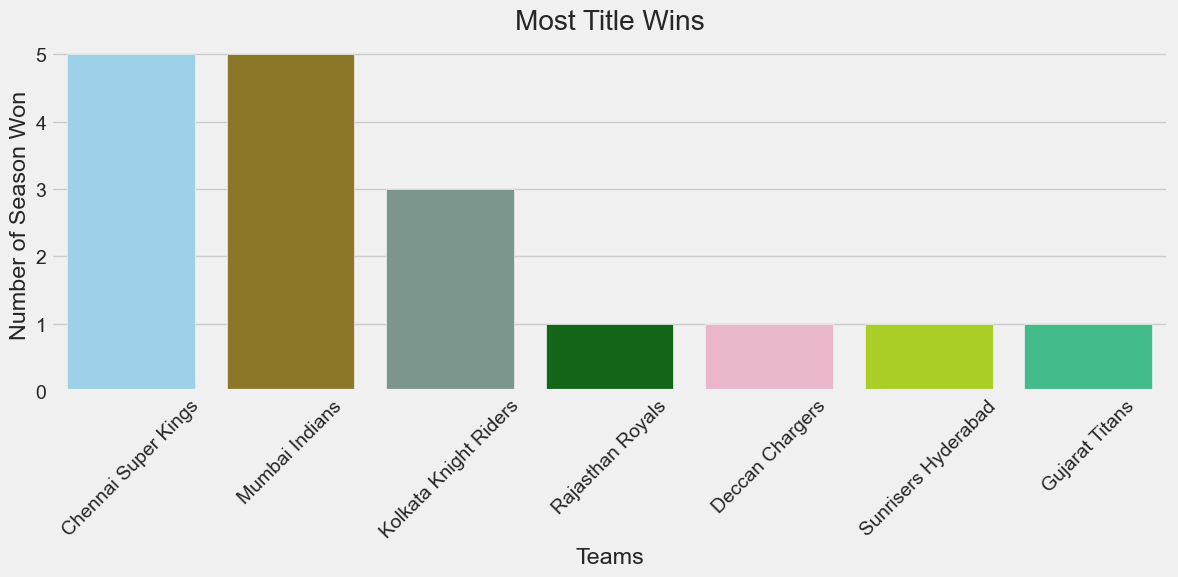

In [26]:
winner_counts = df_match.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()


plt.figure(figsize=(12,6))
sns.barplot(x=winner_counts.index,y=winner_counts.values, palette=random_colors(len(winner_counts)))
plt.title('Most Title Wins')
plt.xlabel('Teams')
plt.ylabel('Number of Season Won')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

---Top 10 Players with Most Runs---

C:\Users\Aryan Nigam\AppData\Local\Temp\ipykernel_1212\452263633.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='batter',y='Runs', data= top_batsmen, palette=random_colors(10))


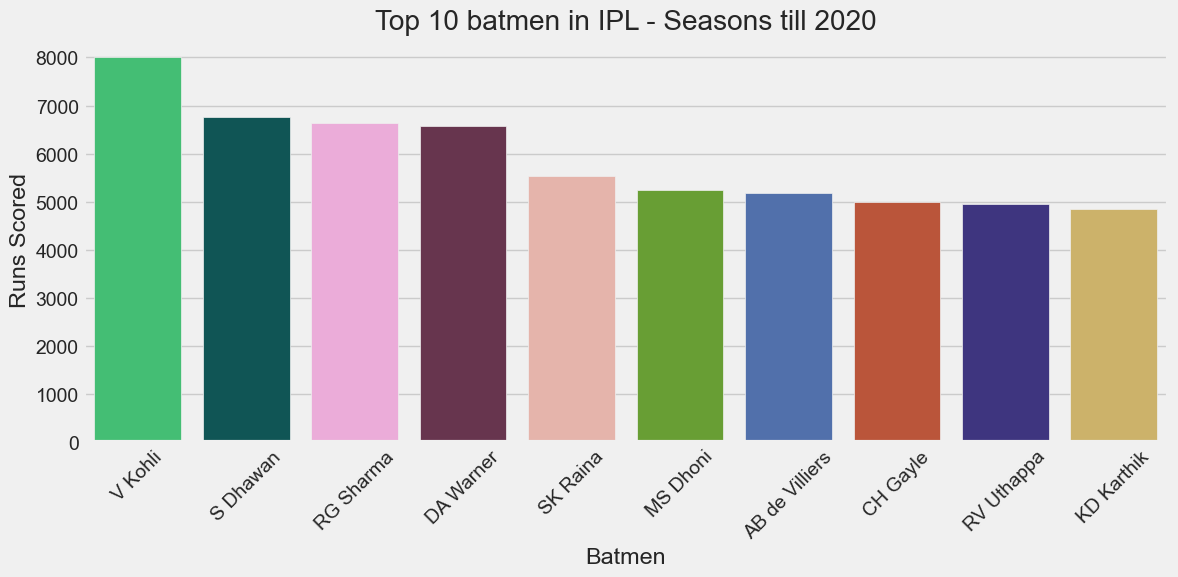

In [27]:
batting_tot = df_del.groupby('batter')['batsman_runs'].sum().reset_index(name='Runs')
top_batsmen = batting_tot.sort_values(by='Runs',ascending=False)[:10]

plt.figure(figsize=(12,6))
sns.barplot(x='batter',y='Runs', data= top_batsmen, palette=random_colors(10))
plt.title('Top 10 batmen in IPL - Seasons till 2020')
plt.xlabel('Batmen')
plt.ylabel('Runs Scored')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

---Top 10 Best Performances in Match---

In [28]:
df_del.head(1)


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


In [29]:
batting_ings = df_del.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index(name='Innings Runs')
top_batsmen_scores = batting_ings.sort_values(by='Innings Runs',ascending=False)[:10]

In [30]:
batsman_ball_faced = df_del.groupby(['match_id', 'batter'])['batsman_runs'].count().reset_index(name='Balls Faced')

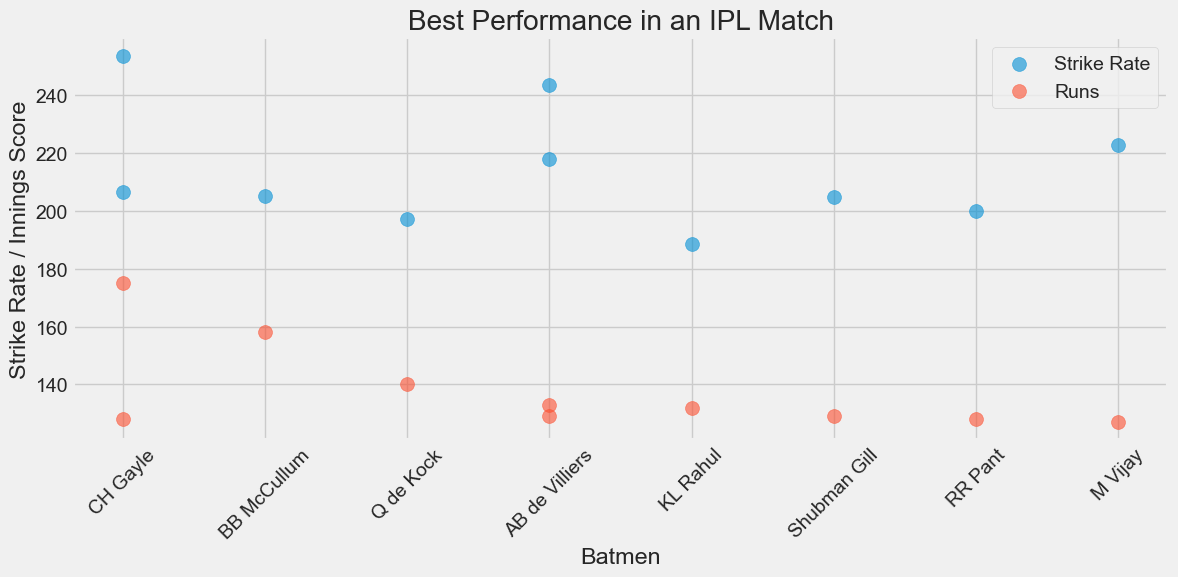

In [31]:
batsmen_performance = pd.merge(top_batsmen_scores,batsman_ball_faced,how='inner', on=['match_id','batter'])
batsmen_performance['Strike Rate for Match'] = np.round(batsmen_performance['Innings Runs']*100/batsmen_performance['Balls Faced'],2)
batsmen_performance

plt.figure(figsize=(12,6))
plt.scatter(batsmen_performance['batter'],batsmen_performance['Strike Rate for Match'], label='Strike Rate',s=100, alpha=0.6)
plt.scatter(batsmen_performance['batter'],batsmen_performance['Innings Runs'], label='Runs',s=100, alpha=0.6)
plt.title('Best Performance in an IPL Match')
plt.xlabel('Batmen')
plt.ylabel('Strike Rate / Innings Score')
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

---Top 10 Bowlers Till 2020---

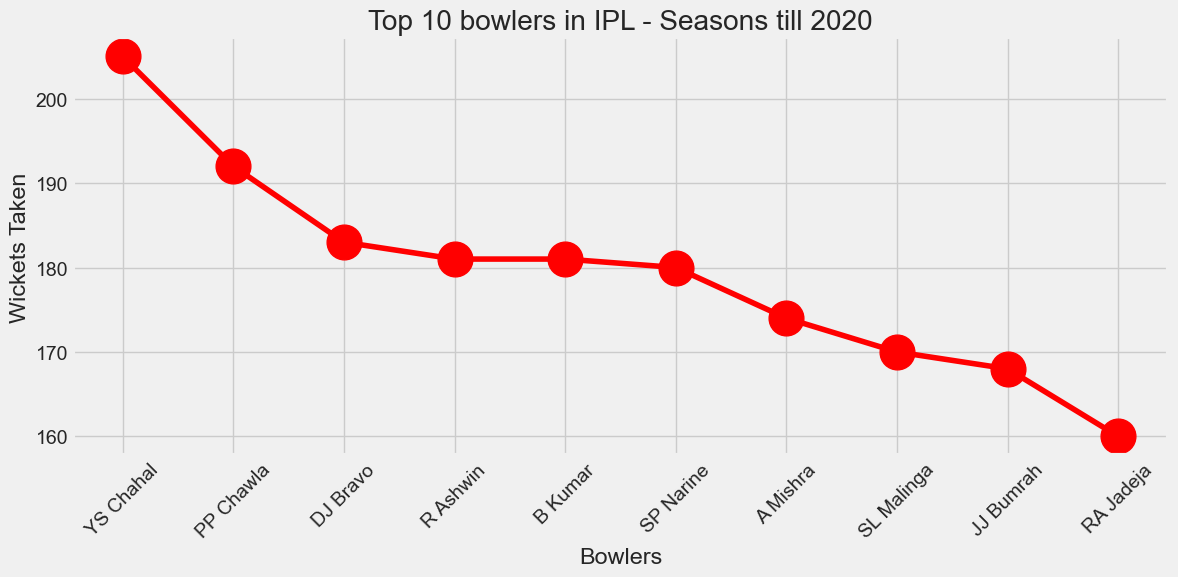

In [32]:
bowling_wickets = df_del[df_del['dismissal_kind'] != 'run out']
top_bowlers = bowling_wickets.groupby('bowler')['dismissal_kind'].count().reset_index(
    name='Wickets').sort_values(by='Wickets',ascending=False)[:10]

plt.figure(figsize=(12,6))
plt.plot(top_bowlers['bowler'],top_bowlers['Wickets'], marker= 'o',color='red',ms=25)
plt.title('Top 10 bowlers in IPL - Seasons till 2020')
plt.xlabel('Bowlers')
plt.ylabel('Wickets Taken')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

---Top 10 Bowling Performances till 2020---

In [33]:
match_bowling_top = bowling_wickets.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index(
    name='Wickets').sort_values(by='Wickets',ascending=False)[:10]

In [34]:
match_bowler_runs = df_del.groupby(['match_id','bowler'])['total_runs'].sum().reset_index(name='Runs Conceded')

In [35]:
match_bowler_performance = pd.merge(match_bowler_runs,match_bowling_top,how='inner', on =['match_id','bowler'])

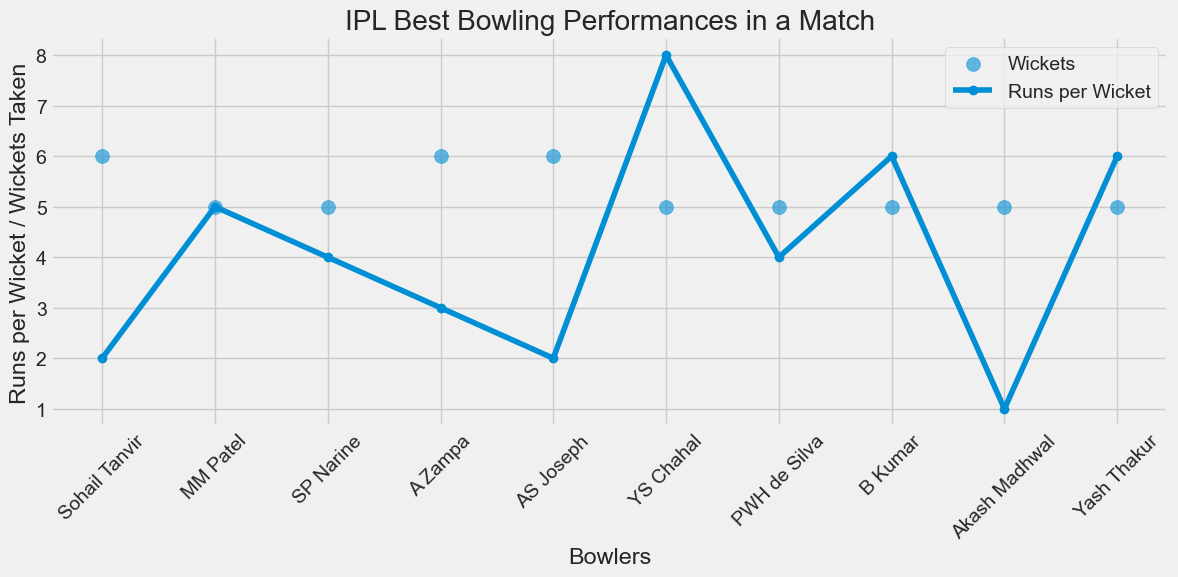

In [36]:
match_bowler_performance['Runs per Wicket'] = np.round(match_bowler_performance['Runs Conceded']/match_bowler_performance['Wickets'],0)


plt.figure(figsize=(12,6))
plt.scatter(match_bowler_performance['bowler'],match_bowler_performance['Wickets'],label='Wickets',s=100,alpha=0.6)
plt.plot(match_bowler_performance['bowler'],match_bowler_performance['Runs per Wicket'],marker='o',label='Runs per Wicket')
plt.title('IPL Best Bowling Performances in a Match')
plt.xlabel('Bowlers')
plt.ylabel('Runs per Wicket / Wickets Taken')
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

---Top 10 Cities by No. of Matches---

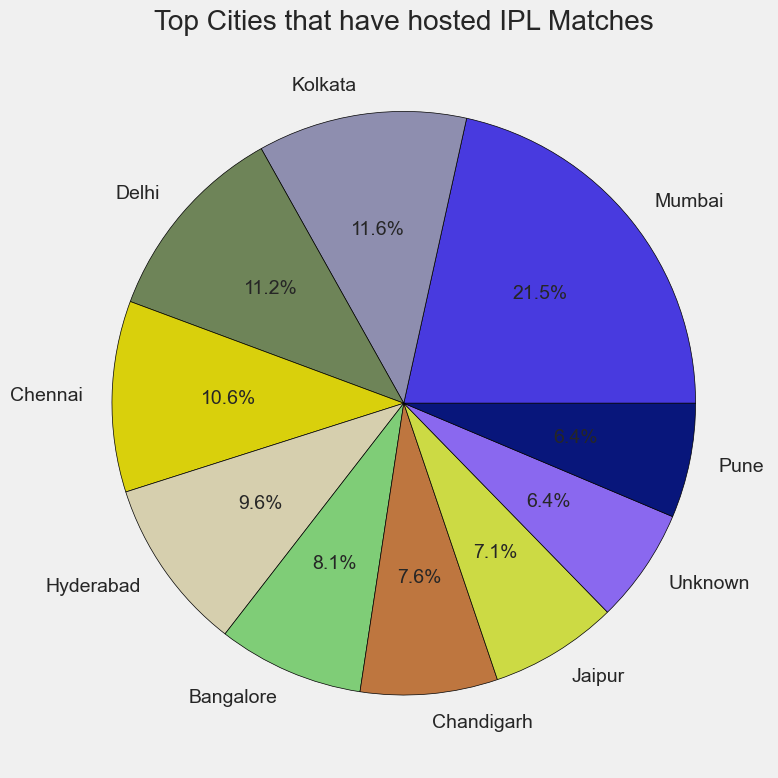

In [37]:
top_cities = df_match['city'].value_counts().reset_index(name='Match Count')[:10]

plt.figure(figsize=(8,8))
plt.pie(top_cities['Match Count'], labels = top_cities['city'],colors=random_colors(10),
       autopct='%1.1f%%', wedgeprops=dict(edgecolor='black'))
plt.title('Top Cities that have hosted IPL Matches')
plt.tight_layout()
plt.show()

---Top Dismissal Kinds---

C:\Users\Aryan Nigam\AppData\Local\Temp\ipykernel_1212\659333875.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dismissal_kind',data=df_del,palette=random_colors(len(df_del['dismissal_kind'].value_counts())))


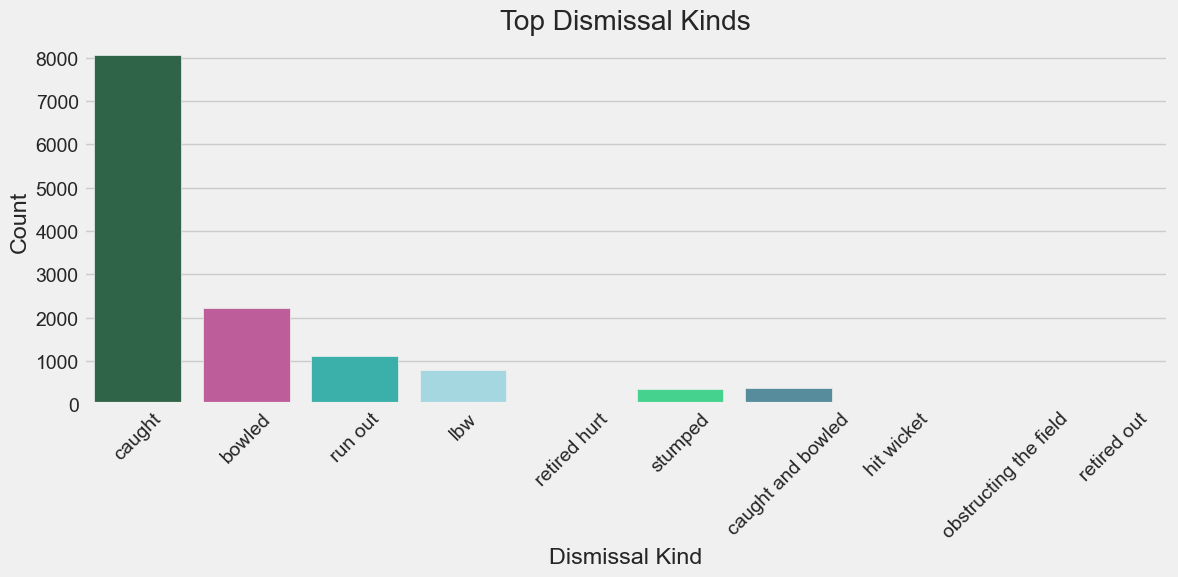

In [38]:
plt.figure(figsize=(12,6))
sns.countplot(x='dismissal_kind',data=df_del,palette=random_colors(len(df_del['dismissal_kind'].value_counts())))
plt.title('Top Dismissal Kinds')
plt.xlabel('Dismissal Kind')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

---Top 10 Best Fielders---

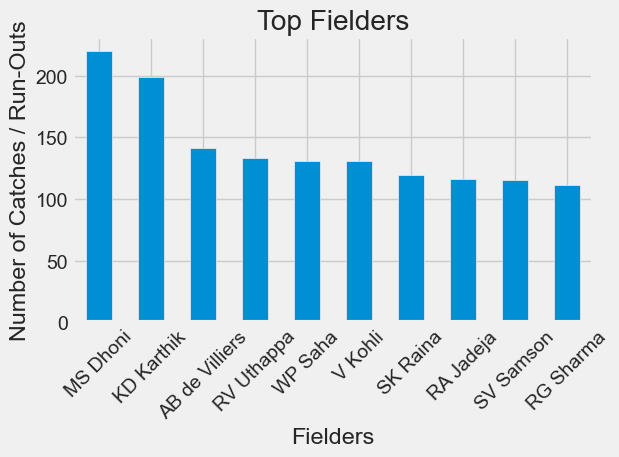

In [39]:
df_del['fielder'].value_counts()[:10].plot(kind='bar')
plt.title('Top Fielders')
plt.xlabel('Fielders')
plt.ylabel('Number of Catches / Run-Outs')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

---Analysis Over By Over---

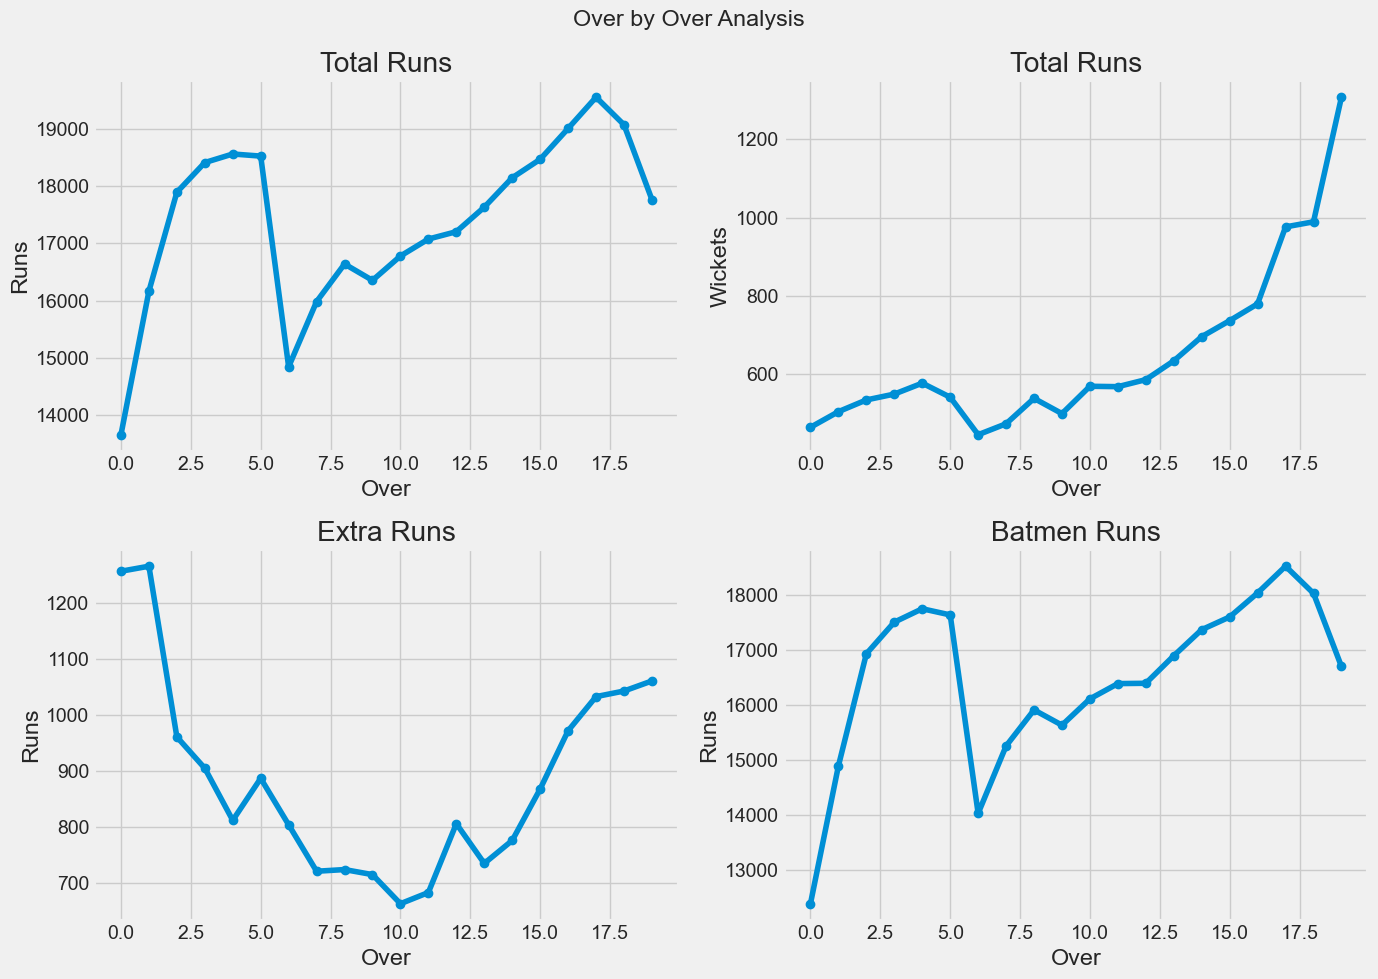

In [40]:
over_summary = df_del.groupby('over')[['total_runs','is_wicket','extra_runs','batsman_runs']].sum()

fig, axes = plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Over by Over Analysis')


axes[0,0].plot(over_summary.index,over_summary['total_runs'],marker='o')
axes[0,0].set_title('Total Runs')
axes[0,0].set_xlabel('Over')
axes[0,0].set_ylabel('Runs')

axes[0,1].plot(over_summary.index,over_summary['is_wicket'],marker='o')
axes[0,1].set_title('Total Runs')
axes[0,1].set_xlabel('Over')
axes[0,1].set_ylabel('Wickets')

axes[1,0].plot(over_summary.index,over_summary['extra_runs'],marker='o')
axes[1,0].set_title('Extra Runs')
axes[1,0].set_xlabel('Over')
axes[1,0].set_ylabel('Runs')

axes[1,1].plot(over_summary.index,over_summary['batsman_runs'],marker='o')
axes[1,1].set_title('Batmen Runs')
axes[1,1].set_xlabel('Over')
axes[1,1].set_ylabel('Runs')

plt.tight_layout()
plt.show()

---Top Decisions---

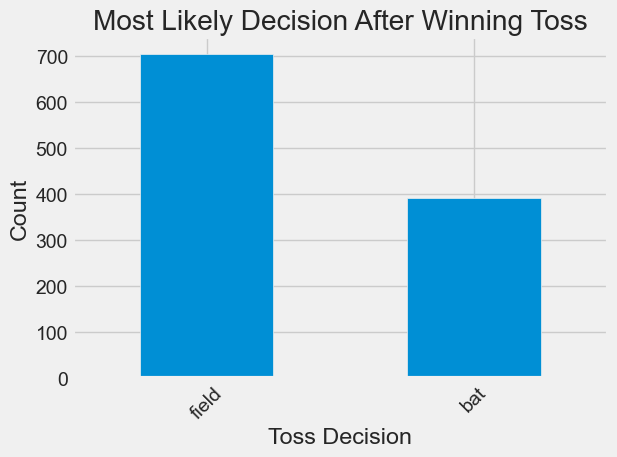

In [41]:
df_match['toss_decision'].value_counts().plot(kind='bar')
plt.title('Most Likely Decision After Winning Toss')
plt.xlabel('Toss Decision')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()